Összesen 3064 képet találtunk


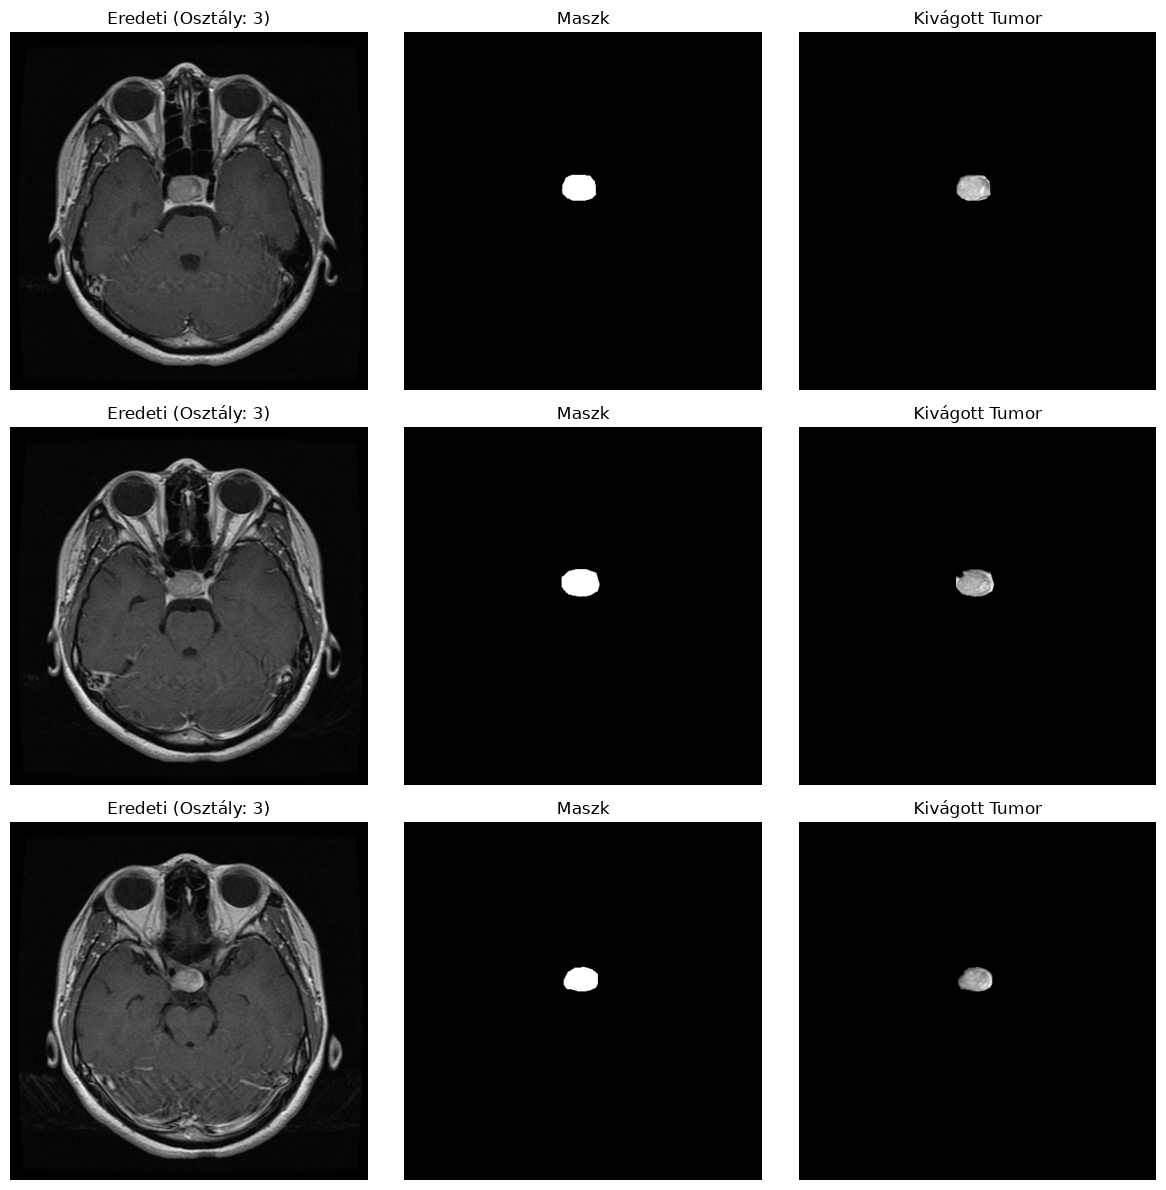

In [8]:
import os
import glob
import matplotlib.pyplot as plt
import cv2

# Útvonalak beállítása:
images_dir = r"..\data\raw\agyikepek_3_osztaly\kepek"
masks_dir = r"..\data\raw\agyikepek_3_osztaly\maskkep"

# Kép keresés
image_paths = sorted(glob.glob(os.path.join(images_dir, "*.*")))

print(f"Összesen {len(image_paths)} képet találtunk")

if len(image_paths) > 0:
    num_images_to_show = 3
    fig, axes = plt.subplots(num_images_to_show, 3, figsize=(12, 4 * num_images_to_show))
    
    found_pairs = 0
    
    # Végigmegyünk a képeken, de csak addig, amíg meg nem találunk 3 párost
    for img_path in image_paths:
        if found_pairs >= num_images_to_show:
            break
            
        filename = os.path.basename(img_path)
        label = filename.split('_')[-1].split('.')[0]
        
        # A megfelelő maszk útvonala
        mask_name_no_ext = os.path.splitext(filename)[0]
        mask_path = os.path.join(masks_dir, mask_name_no_ext + ".png")
        if not os.path.exists(mask_path):
            mask_path = os.path.join(masks_dir, mask_name_no_ext + ".jpg")

        # Ellenőrizzük, létezik-e a maszk fájl
        if not os.path.exists(mask_path):
            # Ha nincs maszk, megyünk a következő képre
            continue

        # Képek beolvasása szürkeárnyalatosként
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Biztosítjuk, hogy a maszk teljesen fekete-fehér legyen
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        
        # Maszkolás: Rávágjuk a maszkot az eredeti képre
        masked_img = cv2.bitwise_and(img, img, mask=mask)

        # 1. Oszlop: Eredeti kép
        axes[found_pairs, 0].imshow(img, cmap='gray')
        axes[found_pairs, 0].set_title(f"Eredeti (Osztály: {label})")
        axes[found_pairs, 0].axis('off')
        
        # 2. Oszlop: Maszk
        axes[found_pairs, 1].imshow(mask, cmap='gray')
        axes[found_pairs, 1].set_title("Maszk")
        axes[found_pairs, 1].axis('off')
        
        # 3. Oszlop: Kivágott tumor
        axes[found_pairs, 2].imshow(masked_img, cmap='gray')
        axes[found_pairs, 2].set_title("Kivágott Tumor")
        axes[found_pairs, 2].axis('off')
        
        found_pairs += 1

    if found_pairs == 0:
        print("Egyetlen képhez sem találtam megfelelő maszkot. Ellenőrizd a mappák tartalmát és neveit!")
    else:
        plt.tight_layout()
        plt.show()
else:
    print("Nem találhatók képek. Ellenőrizd a mappák útvonalát!")


